### Chargement 

Dataset: 920 rows, 16 columns
Missing values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

After cleaning: 299 rows remaining

Class distribution:
num
0    160
1     56
2     35
3     35
4     13
Name: count, dtype: int64

── Model Performance ──────────────────
  Accuracy    : 0.5667
  Precision   : 0.4966
  Recall      : 0.5667
  F1 Score    : 0.5238

── Full Report ────────────────────────
              precision    recall  f1-score   support

           0       0.79      0.94      0.86        32
           1       0.20      0.09      0.12        11
           2       0.00      0.00      0.00         7
           3       0.33      0.43      0.38         7
           4       0.00      0.00      0.00         3

    accuracy                           0.57        60

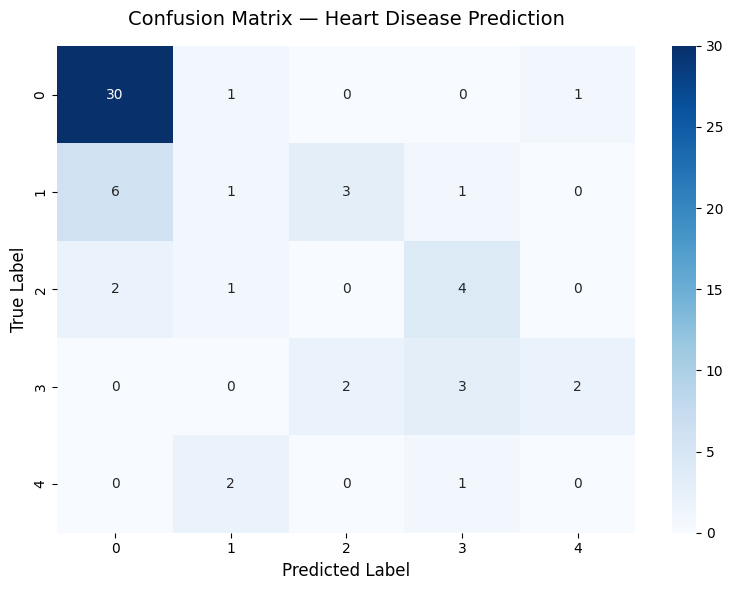

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    classification_report
)

# ══════════════════════════════════════════════════════════
# 1. LOAD
# Read the CSV file into a DataFrame (a table with rows & columns)
# Then print a quick summary: size and any missing values
# ══════════════════════════════════════════════════════════
df = pd.read_csv("heart_disease_uci.csv")

print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing values:\n{df.isnull().sum()}\n")

# ══════════════════════════════════════════════════════════
# 2. CLEAN
# Remove any row that contains at least one missing value.
# We reassign df instead of using inplace=True — cleaner and safer.
# ══════════════════════════════════════════════════════════
df = df.dropna()

print(f"After cleaning: {df.shape[0]} rows remaining\n")

# ══════════════════════════════════════════════════════════
# 3. FEATURES & TARGET
# TARGET is the column the model must learn to predict:
#   0 = no heart disease, 1-4 = increasing severity
#
# X = all other columns (the inputs / features)
# y = the target column (the answer we want to predict)
#
# pd.get_dummies() converts text columns into numeric 0/1 columns
# because ML models only understand numbers.
# drop_first=True removes one redundant dummy column per category
# (e.g. if sex has "male"/"female", we only need one column)
# ══════════════════════════════════════════════════════════
TARGET = "num"

X = pd.get_dummies(df.drop(columns=TARGET), drop_first=True)
y = df[TARGET]

# Good to check: is the dataset balanced across classes?
# A big imbalance (e.g. 90% class 0) can mislead accuracy scores
print(f"Class distribution:\n{y.value_counts()}\n")

# ══════════════════════════════════════════════════════════
# 4. SPLIT — Train set vs Test set
# We train the model on 80% of the data, then evaluate it
# on the remaining 20% it has never seen — like a final exam.
#
# stratify=y → keeps the same class proportions in both sets.
# Without this, the test set could by chance contain too few
# disease cases, making evaluation unreliable.
#
# random_state=42 → fixes the random shuffle so results are
# reproducible every time you run the script.
# ══════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ══════════════════════════════════════════════════════════
# 5. SCALE — Standardize feature values
# Logistic Regression is sensitive to feature scale.
# Age (20–80) and cholesterol (100–400) are very different ranges,
# which confuses the model and slows convergence.
# StandardScaler transforms each column to mean=0, std=1.
#
# IMPORTANT: fit_transform() on train (learn the scale from train data)
#            transform() only on test (apply the same scale — no peeking)
# Fitting on test data would be "data leakage" — the model would
# indirectly see test information before evaluation.
# ══════════════════════════════════════════════════════════
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ══════════════════════════════════════════════════════════
# 6. TRAIN
# Logistic Regression finds the best weights for each feature
# so that the combination predicts the target as accurately as possible.
#
# max_iter=1000 gives the algorithm enough iterations to converge.
# The default (100) is often too low for datasets with many features.
# ══════════════════════════════════════════════════════════
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# ══════════════════════════════════════════════════════════
# 7. EVALUATE
# model.predict() runs the trained model on unseen test data.
# We then compare its predictions (y_pred) to the real answers (y_test).
#
# Metrics explained:
#   Accuracy  → % of all predictions that are correct
#   Precision → when it predicts a class, how often is it right?
#   Recall    → of all real cases of a class, how many did it catch?
#   F1 Score  → harmonic mean of Precision and Recall (balance of both)
#
# average='weighted' → accounts for class imbalance by weighting
# each class by how many samples it has.
#
# zero_division=0 → avoids warnings when a class has no predictions
# (can happen with rare classes in small test sets)
# ══════════════════════════════════════════════════════════
y_pred = model.predict(X_test)

metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
    "Recall":    recall_score(y_test, y_pred, average="weighted", zero_division=0),
    "F1 Score":  f1_score(y_test, y_pred, average="weighted", zero_division=0),
}

print("── Model Performance ──────────────────")
for name, value in metrics.items():
    print(f"  {name:<12}: {value:.4f}")   # :<12 pads the label to align values

# classification_report gives a full per-class breakdown in one table:
# shows precision, recall, F1 and support (sample count) for each class
print("\n── Full Report ────────────────────────")
print(classification_report(y_test, y_pred, zero_division=0))

# ══════════════════════════════════════════════════════════
# 8. CONFUSION MATRIX
# A grid where:
#   rows    = actual (true) labels
#   columns = predicted labels
#   diagonal (top-left → bottom-right) = correct predictions
#   off-diagonal cells                 = mistakes
#
# The darker the blue, the more predictions fell in that cell.
# A perfect model would show numbers only on the diagonal.
#
# plt.savefig() saves the chart as an image file so you
# don't lose it when the script finishes running.
# ══════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,   # write the count number inside each cell
    fmt="d",      # format numbers as integers (not scientific notation)
    cmap="Blues", # color palette — darker = higher count
    ax=ax
)

ax.set_title("Confusion Matrix — Heart Disease Prediction", fontsize=14, pad=15)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)

plt.tight_layout()                          # prevents labels from being cut off
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()